# Lab 1 — Evasion Attack: a printable patch that turns a speed-limit sign into a STOP

### Adversarial machine learning for autonomous vehicles

This lab demonstrates an **evasion attack**. The model is left completely untouched — we
only modify the **input the camera sees**. A small, printable patch added to a real
**30 km/h** speed-limit sign makes a well-trained traffic-sign classifier read it as **Stop**.

This is the threat made famous by *Eykholt et al., Robust Physical-World Attacks on Deep
Learning Visual Classification (CVPR 2018)* — the "stickers on a stop sign" result. We run
the attack from the KASTEL Mobility Lab repo against its **most vulnerable** model,
**CNN-small (LISA-CNN)**.

**Threat model:** the attacker cannot change the model or its weights. They can only place a
sticker on a physical sign.

**Roadmap**
1. Load the victim classifier and confirm it reads the real sign correctly.
2. Warm-up intuition: a tiny digital gradient perturbation already breaks it.
3. The physical patch attack (pre-computed) → the sign is read as **Stop**.
4. Why it matters, and defenses.

## 0. Setup

All lab code lives in `tsr-labs/`, **outside** the cloned research repo (which stays
read-only). `lab_common` puts that repo on the import path so we can reuse its `utils` and
`models`, and it picks a compute device — the repo hardcodes CUDA, so on a Mac we fall back
to Apple **MPS** (or CPU).

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

import lab_common as lc
import utils, models          # imported from the read-only repo via lab_common

device = lc.pick_device()
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.12.0 | device: mps


## 1. The victim: a traffic-sign classifier

We load **CNN-small** with the repo's pretrained GTSRB weights (43 German traffic-sign
classes, ~98% test accuracy). This is a normal, well-trained model — nothing about it is
compromised. Our target class is **14 = Stop**.

In [2]:
SIGN_PATH = os.path.join(lc.ATTACK_UTILS_DIR, "30kmh.jpg")
ART_DIR   = os.path.join(lc.ARTIFACT_DIR, "lab1_precomputed_CNNsmallGTSRB")

params = lc.build_base_params("GTSRB")
params["DEVICE"]      = device
params["MODEL_TYPE"]  = "CNNsmall"
params["PATH_MODEL"]  = os.path.join(lc.MODELS_DIR, "CNNsmallGTSRB.pth")
params["TARGET_CLASS"] = 14                      # 14 = Stop
labels = params["LABELS"]

model = utils.load_model(params)                 # repo's loader; weights map onto MPS/CPU
print(type(model).__name__, "loaded —", params["CLASS_N"], "GTSRB classes")
print("Target class:", labels[params["TARGET_CLASS"]])

CNNsmall loaded — 43 GTSRB classes
Target class: 14:Stop


## 2. Baseline — the model reads the real sign correctly

A sanity check on the genuine 30 km/h sign: the model should be confident and correct, with
near-zero probability on *Stop*.

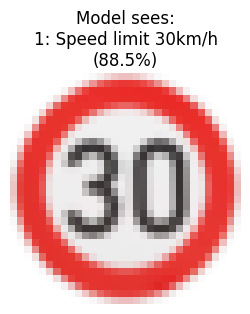

Confidence in 'Stop' (class 14): 0.25%


In [3]:
to32 = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])
orig = torch.clamp(to32(Image.open(SIGN_PATH)), 0, 1)

idx, conf, probs = lc.predict_one(model, orig, device)
plt.figure(figsize=(3, 3))
plt.imshow(orig.permute(1, 2, 0).cpu()); plt.axis("off")
plt.title(f"Model sees:\n{labels[idx]}\n({conf*100:.1f}%)")
plt.show()
print(f"Confidence in 'Stop' (class 14): {probs[14]*100:.2f}%")

## 3. Warm-up intuition: a tiny digital perturbation

Before the physical patch, here is the simplest adversarial example. Using the model's own
gradients, **PGD** nudges every pixel by a tiny, bounded amount (L∞ ≤ 0.03, i.e. ≲ 8 levels
out of 255 — barely visible) to *maximise* the model's error.

The result: a confident **30 km/h** becomes a confident **50 km/h**. A car would now obey the
wrong speed limit.

This is a *digital* attack — it assumes the attacker can edit the exact pixels the model
receives, which is unrealistic for a camera looking at a real sign. But it makes the core
point: **classifiers are fragile to small, carefully-chosen input changes.** The physical
patch attack next lifts this into the real world.

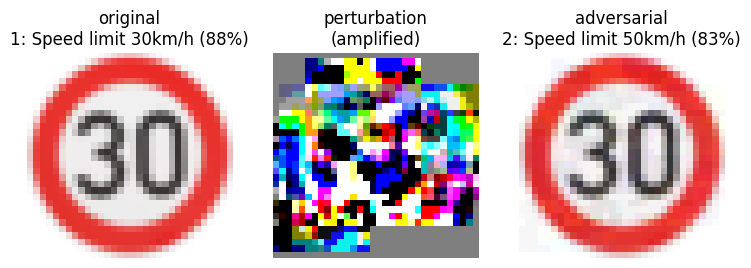

Max pixel change (L-inf): 0.030  (image values are in [0, 1])


In [4]:
adv = lc.pgd(model, orig, label=idx, targeted=False,
              eps=0.03, alpha=0.03/8, steps=30, device=device)

i_o, c_o, _ = lc.predict_one(model, orig, device)
i_a, c_a, _ = lc.predict_one(model, adv,  device)
diff = adv - orig
amp  = (diff - diff.min()) / (diff.max() - diff.min() + 1e-9)   # rescale for display

fig, ax = plt.subplots(1, 3, figsize=(9, 3.3))
for a in ax: a.axis("off")
ax[0].imshow(orig.permute(1, 2, 0).cpu()); ax[0].set_title(f"original\n{labels[i_o]} ({c_o*100:.0f}%)")
ax[1].imshow(amp.permute(1, 2, 0).cpu());  ax[1].set_title("perturbation\n(amplified)")
ax[2].imshow(adv.permute(1, 2, 0).cpu());  ax[2].set_title(f"adversarial\n{labels[i_a]} ({c_a*100:.0f}%)")
plt.show()
print(f"Max pixel change (L-inf): {float(diff.abs().max()):.3f}  (image values are in [0, 1])")

## 4. The physical patch attack

A real attacker cannot edit a camera's pixels — but they **can** stick a printed patch on the
sign. The repo's attack optimises such a patch in two stages:

1. **Mask initialisation** — learn *where* on the sign a patch most efficiently changes the
   prediction.
2. **Patch optimisation** — optimise the patch's colours while applying random
   rotations / brightness / contrast each step (*differentiable augmentation*), so the patch
   keeps working under real-world viewing conditions (different angles, lighting).

This runs a few thousand optimisation steps — minutes of compute, with hundreds of
intermediate plots. So we ran it **once, offline** with `precompute_lab1.py` (which calls the
repo's `utils.train_attack` / `utils.test_attack`) and saved the result. Here we just **load**
it.

> Note: the paper's *inconspicuous* (grayscale, tiny) patch cannot reach a class as visually
> distant as Stop on this model — so we use a small but **visible coloured patch**, the kind an
> attacker could print and stick on a sign.

> If the next cell raises `FileNotFoundError`, run `python precompute_lab1.py` once inside
> `tsr-labs/` first (a few minutes), then re-run.

In [5]:
pert_path = os.path.join(ART_DIR, "pert_sign_large.png")
if not os.path.exists(pert_path):
    raise FileNotFoundError(
        "Pre-computed patch not found. Run this once first (in tsr-labs/):\n"
        "    python precompute_lab1.py\n"
        f"Expected file: {pert_path}")

pert = torch.clamp(to32(Image.open(pert_path)), 0, 1)
print("Loaded the pre-computed perturbed sign.")

Loaded the pre-computed perturbed sign.


## 5. The result — same sign, opposite decision

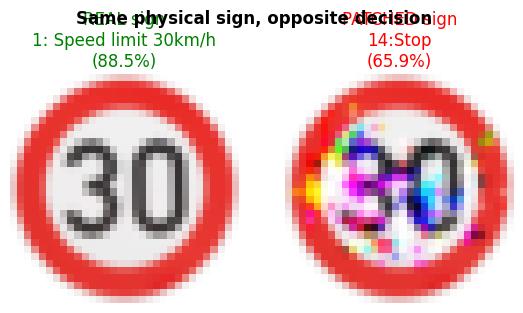

'Stop' confidence:  real sign  0.25%   ->   patched sign 65.92%
Attack succeeded: the patched 30 km/h sign is read as STOP.


In [6]:
i_o, c_o, p_o = lc.predict_one(model, orig, device)
i_p, c_p, p_p = lc.predict_one(model, pert, device)

fig, ax = plt.subplots(1, 2, figsize=(6.5, 3.7))
for a in ax: a.axis("off")
ax[0].imshow(orig.permute(1, 2, 0).cpu())
ax[0].set_title(f"REAL sign\n{labels[i_o]}\n({c_o*100:.1f}%)", color="green")
ax[1].imshow(pert.permute(1, 2, 0).cpu())
ax[1].set_title(f"PATCHED sign\n{labels[i_p]}\n({c_p*100:.1f}%)", color="red")
plt.suptitle("Same physical sign, opposite decision", fontweight="bold")
plt.show()

print(f"'Stop' confidence:  real sign {p_o[14]*100:5.2f}%   ->   patched sign {p_p[14]*100:5.2f}%")
assert i_p == 14, "Expected the patched sign to be classified as Stop."
print("Attack succeeded: the patched 30 km/h sign is read as STOP.")

## 6. Why this matters, and defenses

**What happened:** a few square centimetres of printed pattern flipped a confident *30 km/h*
into a confident *Stop* — without touching the model. A car braking for a phantom stop sign on
a motorway is a safety hazard; a stop sign read as a speed limit is worse.

**Why CNN-small is so vulnerable:** the paper shows task-specific baselines (LISA-CNN /
GTSRB-CNN) are markedly more susceptible than generic backbones.

**Defenses:** adversarial training; input transformations / denoising; randomized smoothing;
sensor fusion and temporal consistency (a real sign does not flicker between classes);
physical-world detectors for anomalous patches.

**Contrast with Lab 2:** here the *model* was honest and we attacked the *input*. In the
data-poisoning lab we corrupt the *training data*, so the model itself hides a backdoor.

## 7. (Optional) Watch a shorter attack optimise live

For the curious: set `RUN_LIVE = True` to optimise a fresh patch here (~1–2 min on MPS). It
uses far fewer epochs, so the patch is weaker and may not fully converge — the pre-computed
artifact above is the reliable demo. Plots from the inner loop are suppressed via
`lc.suppress_plots()`.

In [7]:
RUN_LIVE = False  # set True to optimise a (weaker) patch live

if RUN_LIVE:
    live = lc.lab1_patch_params(
        out_dir=os.path.join(lc.ARTIFACT_DIR, "lab1_live"),
        device=device, attack_epochs=1200, init_mask_epochs=300)
    os.makedirs(live["OUTPUT_DIR"], exist_ok=True)
    with lc.suppress_plots():
        utils.train_attack(live)
        utils.test_attack(live)
    live_pert = torch.clamp(to32(Image.open(live["PATH_PERT_SIGN_LARGE"])), 0, 1)
    li, lc_, _ = lc.predict_one(model, live_pert, device)
    print(f"Live patch -> {labels[li]} ({lc_*100:.1f}%)")
else:
    print("RUN_LIVE is False — skipping the live attack.")

RUN_LIVE is False — skipping the live attack.
